In [84]:
import tensorflow as tf  #basic ML framework
from tensorflow.keras.preprocessing.image import ImageDataGenerator # For loading & augmenting images
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [85]:
DATA_DIR = "Dataset"
IMG_SIZE = (128, 128)
BATCH_SIZE = 8

In [86]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,       # Using 20% of data for validation
    rotation_range=20,          # Randomize
    zoom_range=0.1,             # Randomize
    horizontal_flip=True)       # Randomize

In [87]:
!rm -rf Dataset/.ipynb_checkpoints

In [88]:
import os
print(os.listdir("Dataset"))

['infected', 'healthy']


In [89]:
train = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

Found 16 images belonging to 2 classes.


In [90]:
val = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 4 images belonging to 2 classes.


In [91]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)), # 32 filters of size 3x3
    layers.MaxPooling2D(2,2), # reduce size by half

    layers.Conv2D(64, (3,3), activation='relu'),   # 64 filters learn more detailed patterns
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),  # 128 filters for complex features
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),                           # Dropout to prevent overfitting

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [105]:
history = model.fit(
    train,
    validation_data=val,
    epochs=10
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 380ms/step - accuracy: 0.7083 - loss: 0.5962 - val_accuracy: 0.5000 - val_loss: 0.7247
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step - accuracy: 0.7917 - loss: 0.5605 - val_accuracy: 0.7500 - val_loss: 0.6842
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 0.7917 - loss: 0.4661 - val_accuracy: 0.7500 - val_loss: 0.8141
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step - accuracy: 0.8333 - loss: 0.4140 - val_accuracy: 0.7500 - val_loss: 0.5923
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 312ms/step - accuracy: 0.7917 - loss: 0.3833 - val_accuracy: 0.7500 - val_loss: 0.7156
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 0.8333 - loss: 0.3503 - val_accuracy: 0.7500 - val_loss: 1.0724
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.9167 - loss: 0.2672 - val_accuracy: 0.5000 - val_loss: 2.2218
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 316ms/step - accuracy: 0.8750 - loss: 0.2598 - val_accuracy: 0.7500 - val_loss:

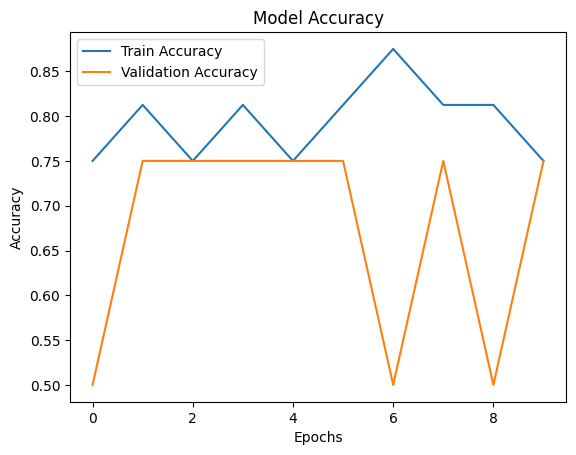

In [106]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [107]:
from tensorflow.keras.preprocessing import image

In [109]:
img_path = "test_img.jpg"

In [110]:
img = image.load_img(img_path, target_size=IMG_SIZE)
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

In [111]:
pred = model.predict(x)[0][0]
label = "Infected" if pred >= 0.5 else "Healthy"      # Threshold = 0.5
confidence = pred if pred >= 0.5 else 1 - pred
print(f"Predicted: {label} (Confidence: {confidence: })")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted: Infected (Confidence:  0.987274169921875)
